

---




# Exploring the Relationship Between Football Associations and Top 50% Country Ranking


## Introduction
Soccer also known as football is considered as the most famous sport in the world. It has a massive global following and is played and watched by millions of people across various continents. one of the major tournament in this sport is the FIFA world Cup where each continent is represented by a number of team. FIFA the global governing body for the sport of soccer release each month table that rank these countries based on their perfomance--wins or loses.
In this analysis, the data we will be working with teams ranking before Qatar 2022 World Cup. this data contains a total of 211 teams, six associations, points and previous points, and rank and previous rank of each teams. Having teams in the top rank is the main goal of association in the FIFA ranking. However, some Association are more represented than others in the top 50.
This analyse uses data from the fifa ranking to predict association of teams in the top 50. top 50 is a binary variable that has a value of one for teams in the top 50 and 0 for teams not in the top 50.

## Research question:

Does association predict a country being in the top 50%?

---






---

# Analysis
with the aim of responding to the question, we used the rank variable from the fifa ranking data to create a new variable called top_50 which is a continuous binary variable and also our response variable. And since we are concerned about the asociations, we find it necessary to group the data by association, take the mean of each association and count the number of teams in each association. By doing so, we came up with the following table (table 1).
<br>

| Association | Mean_rank_by_region | number_of_teams  |
| ----------- | -----------         | ---------------  |
|AFC|124.67 | 46|
|CAF|109.83 | 54|
|CONCACAF|137.57|35 |
|CONMEBOL|31| 10|
|OFC|165.00|11 |
|UEFA|68.23|55 |

<br>

from this table we can see that the CAF(Africa) has the highest number of representatif in the ranking and the CONMEBOl has the lowest number of representatif.
And from the means col, teams in the CONMEBOL(south America) are ranked higher in the fifa ranking and after them come Teams in the UEFA(Europe). Teams in the OFC(Oceania) are placed last in the fifa classement.

The graph below is the visual representation of each association based on their ranking (fig 1).

<br>

![Alt Text](https://github.com/ndabo/images/blob/main/Unknown-2.png?raw=true)

The more the color is blue, the closest the association representatives are in the top 50 and the more the color is red less they are in the top 50.


## Development of my inference model
The Type of model used in this study is the logistic regression because we are working with a binary variable.

### Variables:

Top 50% is a continuous variables (bivariate)
Association is a categorical variable
### Type of Model: Logistic
Below is our linear regression equation:

$Top50=β_0+β_1×C(association)$
- Top 50% is my response variable (continuous)
- Association is my predictor variable (categorical)
- $β_0$ is the intercept term.
- $β_1$ is the coefficient associated with the level of the "association" variable.

To find the intercept term and the coefficient, we used the Logit class from the Statsmodels library to fit a logistic regression model, then we return the summary of that model.

However we couldn't interprete this summary without checking the assumption of the logistic regression.

The first assumption was to check if the response variable was a binary variable. We employed the value_counts method from the Pandas library to determine the number of unique values in the Top_50 variable. Our analysis revealed that it has only two values. With this information, we can confidently conclude that this assumption is satisfied.

The second assumption involved checking for independence. Given that the data is collected on teams, it can be asserted that no team depends on another team. Consequently, there is no dependence in the order of the teams. Additionally, we visually inspected the residuals and observed no cyclical pattern. Thus, the independence assumption was also deemed to be met.

![Alt Img](https://github.com/ndabo/images/blob/main/Unknown-3.png?raw=true)

The third assumption aimed to assess multicollinearity. However, The absence of multiple predictors in our model ensures that multicollinearity is not a relevant consideration.

The fourth step involved examining extreme residuals in logistic regression. We utilized the describe() method on the deviance residuals (resid_dev) of my logistic regression model. Upon inspection, we found that there were no deviance residuals greater than 3. Consequently, we conclude that this assumption has been satisfied.

The fifth step involved examining the linearity assumption. We obtained the 'fitted values' from the logistic regression model and plotted them against the x variables using the sns.catplot. For each categorical value, the plot exhibited a very linear relationship. As a result, we conclude that the linearity assumption has been satisfied.

The final step was to check the sample size assumption. We grouped the data by region and counted the number of observations using the count method in the Pandas library. The assumption was also found to be met.

### Assessing the Model
To evaluate the validity of our model, we appended the predicted probabilities as a new column to our dataframe. Subsequently, we compared these probabilities with the observed classifications of the response variable. Employing a probability threshold of 0.50, we distinguished between predictions indicating whether a team would be in the top 50 or not. We then utilized the classification report, resulting in the creation of Table 2.

|             | Precision| recall           | f1_score | support|
| ----------- | ------   | ---------------  |----------|---------|
|0|0.63 |0.87|0.73|106|
|1|0.78|0.49|0.60|105|
|accuracy|||0.68|211|
|macro avg|0.71|0.68|0.67|211|
|weight avg|0.71|0.68|0.67|211|

The precision is the ratio tp / (tp + fp) where tp is the number of true positives and fp is the number of false positives. The precision is intuitively the ability of the classifier to not label a sample as positive if it is negative.
The recall is the ratio tp / (tp + fn) where tp is the number of true positives and fn is the number of false negatives. The recall is intuitively the ability of the classifier to find all the positive samples.
F-beta score reaches its best value at 1 and worst score at 0. The F-beta score weights the recall more than the precision by a factor of beta. beta = 1.0 means recall and precision are equally important (L.Clark, lab_3).

We also calculates a 95% confidence interval around the odds ratio to build in the inherent uncertainty in our estimate.

| Variable                   |       5% |       95% |   Odds Ratio |
|----------------------------|----------|-----------|--------------|
| Intercept                  | 0.355598 |   1.16217 |  0.642857    |
| C(association)[T.CAF]      | 0.559613 |   2.76734 |  1.24444     |
| C(association)[T.CONCACAF] | 0.282061 |   1.80215 |  0.712963    |
| C(association)[T.CONMEBOL] | 0        | inf       |  1.59298e+09 |
| C(association)[T.OFC]      | 0.018316 |   1.32109 |  0.155556    |
| C(association)[T.UEFA]     | 1.95148  |  10.6345  |  4.55556     |

---






---
# Result

For our model, 78% of instances predicted as positive by the model were correct, indicating a higher precision for the '1.0' class. However, the recall is lower, as the model identified only 48% of all actual positive instances. In summary, the model tends to be correct when predicting the positive class (higher precision), but it may miss some actual positive instances (lower recall).

Interpreting the odds ratio for an association category, a value of 1 suggests no difference in the odds of being in the top 50%. If the odds ratio is greater than 1, it indicates an increase in the odds of being in the top 50% compared to other associations. Conversely, if the odds ratio is less than 1, it suggests a decrease in the odds of being in the top 50% compared to other categories. Consequently, CONMEBOL, UEFA, and CAF have higher odds of being in the top 50%, while CONCACAF and OFC have lesser odds.

Additionally, we found that the likelihood ratio test (LLR) p-value is less than 0.05, indicating that our model is statistically significant compared to a null model. However, the log-likelihood value of -124.22 suggests that the model could be further improved.

Base on the information above, we can conclude that the association is a significant predictor of a country being in the top 50.



---






---

## Discussion
While investigating whether the association predicts a country being in the top 50%, the model we developed did not entirely align with the actual situation, indicating a need for improvement. However, upon examining different regions such as CAF, CONCACAF, CONMEBOL, OFC, and UEFA, it became apparent that certain regions exert more influence on whether a country is in the top 50%.

Specifically, regions like CONMEBOL, UEFA, and CAF demonstrated higher odds of being in the top 50% compared to OFC and CONCACAF. In summary, if a team is affiliated with UEFA, CONMEBOL, or CAF, it is more likely to be in the top 50%.

The limitation and ethical consideration arising from these results are related to the sampling size of each association in the World Cup. The number of teams representing each association varies significantly, which could introduce biases into the analysis. For instance, Europe, with a total of 44 countries, has only 13 representatives in the FIFA World Cup, whereas African countries, totaling 44, have only 5 representatives. This imbalance may impact the reliability of the results.

Furthermore, the sample size for each association is not uniform, with CONMEBOL having the smallest sample of 10 and AFC having 44 representatives, creating a substantial gap between the associations. This discrepancy raises concerns about the equal benefit derived from the model for all associations, indicating the presence of sampling biases. The graph below demonstrate this statement.
![alt text](https://github.com/ndabo/images/blob/main/Unknown-4.png?raw=true).

In ethical terms, this uneven representation may lead to unfair assessments or conclusions, potentially favoring associations with fewer representation while disadvantaging those with larger teams. Addressing this limitation is crucial to ensuring the fairness and validity of the analysis, and efforts should be made to account for or mitigate the impact of sampling size disparities in future research or analyses.
---




Task 6:  Use the head "Appendix" and include your commented code and access to your data to ensure reproducability



---

# Appendix




---




In [ ]:
# Import packages you may need
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from scipy.stats import ttest_ind
import tabulate as table

In [ ]:
# Import gapminder data
drive.mount('/gdrive')
ranking = pd.read_csv('/gdrive/MyDrive/Assignments/fifa_ranking.csv')
ranking.head()

Mounted at /gdrive


,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46


In [ ]:
#checking for missing information and duplicated info
ranking.info()
ranking.duplicated().any()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   team             211 non-null    object 
 1   team_code        211 non-null    object 
 2   association      211 non-null    object 
 3   rank             211 non-null    int64  
 4   previous_rank    211 non-null    int64  
 5   points           211 non-null    float64
 6   previous_points  211 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.7+ KB


False

My data has 121 rows and 7 cols. all the data have correct datatype and there's not a missing value and duplicated value.

In [ ]:
#summary of descriptive statistics for each column
ranking.describe()

,rank,previous_rank,points,previous_points
count,211.00000,211.00000,211.000000,211.000000
mean,106.00000,106.00000,1220.687346,1220.645592
std,61.05462,61.05462,253.420954,253.331712
min,1.00000,1.00000,762.220000,763.820000
25%,53.50000,53.50000,1007.675000,1008.330000
50%,106.00000,106.00000,1192.090000,1183.900000
75%,158.50000,158.50000,1433.465000,1431.790000
max,211.00000,211.00000,1841.300000,1837.560000


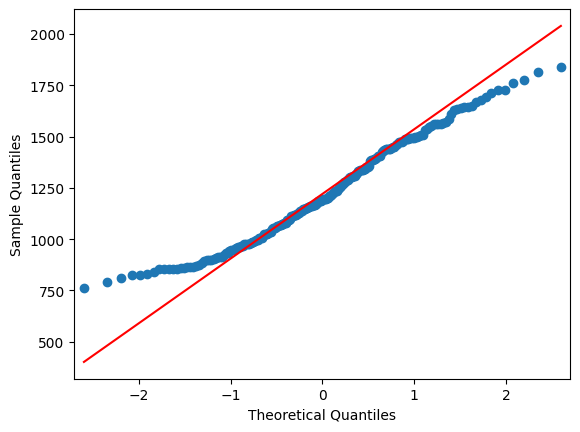

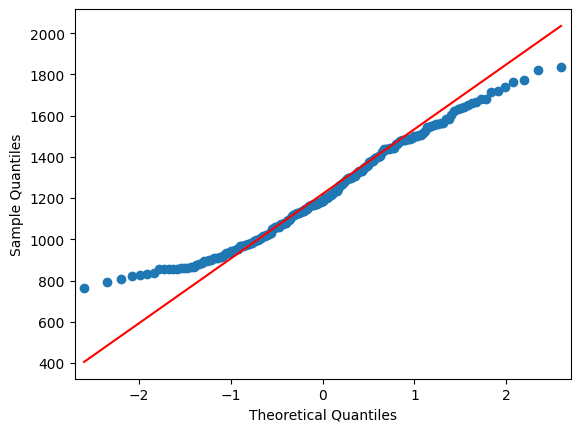

In [ ]:
#qqplot of the variable points
import statsmodels.api as sm
plot_points = sm.qqplot(ranking['points'],line='q')
plot_previous_points = sm.qqplot(ranking['previous_points'],line='q')

both plot form an S-shape,therefore, there is skewness in the distribution of both variable.  the distribution has a longer left tail, and most of the data points are concentrated to the right of the mean.

In [ ]:
#group by association
group_by_region = ranking.groupby('association')
group_by_region.count()


,team,team_code,rank,previous_rank,points,previous_points
association,,,,,,
AFC,46,46,46,46,46,46
CAF,54,54,54,54,54,54
CONCACAF,35,35,35,35,35,35
CONMEBOL,10,10,10,10,10,10
OFC,11,11,11,11,11,11
UEFA,55,55,55,55,55,55


<Axes: title={'center': 'distribution of Association'}, xlabel='associations', ylabel='frequency'>

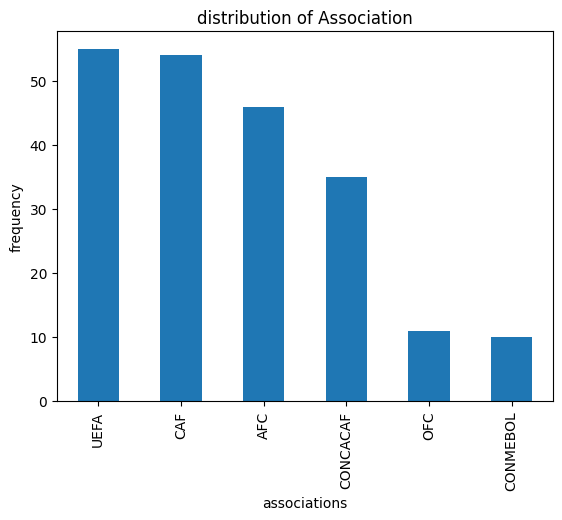

In [ ]:
ranking['association'].value_counts().plot(kind='bar',title = 'distribution of Association', xlabel='associations',ylabel='frequency')

In [ ]:
#get the rank mean of grouped association
mean_rank_by_region = group_by_region['rank'].mean()
print(mean_rank_by_region)

association
AFC         124.673913
CAF         109.833333
CONCACAF    137.571429
CONMEBOL     31.700000
OFC         165.000000
UEFA         68.236364
Name: rank, dtype: float64


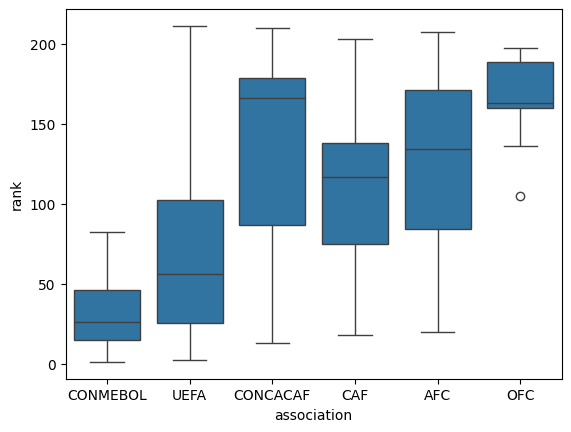

In [ ]:
#boxplot
sns.boxplot(x='association', y='rank', data=ranking)
plt.show()

We can infer from the box plot above that teams in the OFC are generally ranked lower in the fifa ranking and those in the CONMEBOL are generally ranked higher. Teams in these assocition(UEFA,CAF,AFC,CONCACAF) have greater variability. and those on the CONMEBOL and OFC have lower variabilty


<ipython-input-28-d97e80cbbff5>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot (data=ranking, x="association", y='rank', palette='coolwarm')


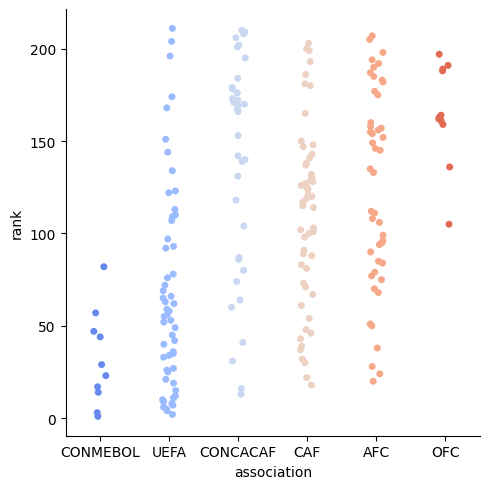

In [ ]:
#plotting the rank of teams in each association
sns.catplot (data=ranking, x="association", y='rank', palette='coolwarm')

In [ ]:
#correlation between teams ranking and their points
ranking['rank'].corr(ranking['points'])

-0.9919902816753412

since this number is closer to negative one, this mean that teams with higher point are on the top of the list. in another word, as the points increases, the rank of the teams get higher.

note: this might be confusing because it should be the opposite. but in our case here, we are working with the variable 'rank'. with this variable the lower the number is the higher is the rank. that's why the interpretation of the correlation is flipped.

below is the graphical representation.

<Axes: xlabel='rank', ylabel='points'>

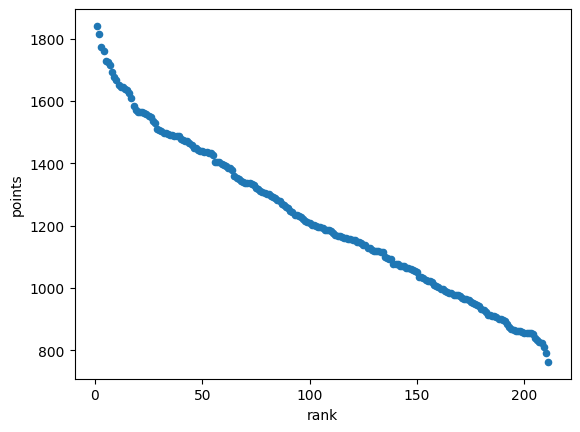

In [ ]:
ranking.plot.scatter('rank','points')

this plot demonstrates what have been said previously. if we use a line on this graph, we will see that it is decreasing. As the point increases, the ranking gethigher meanting tend toward 1.

In [ ]:
#filtering association/region/continent and taking their rank
AFC = ranking[ranking['association'] == 'AFC']['rank']
CAF = ranking[ranking['association'] == 'CAF']['rank']
OFC = ranking[ranking['association'] == 'OFC']['rank']
UEFA = ranking[ranking['association'] == 'UEFA']['rank']
CONMEBOL = ranking[ranking['association'] == 'CONMEBOL']['rank']
CONCACAF = ranking[ranking['association'] == 'CONCACAF']['rank']

considering my question wether there's a difference in ranking between regions or not, the hypotheses will be:

Null Hypothese: there is not a significan difference in ranking between associations.

Alternate hypothese: there is a significant difference in ranking between some of the associations(at least one).

I use spicy.stats.f_oneway to perform this test. to do so, we need to group each association based on their ranking.

In [ ]:
#f_oneway test
from scipy.stats import f_oneway
statistic, p_value = f_oneway(AFC, CAF, OFC, UEFA, CONMEBOL, CONCACAF)

# Print the result
print(f'ANOVA Test Statistic: {statistic}')
print(f'P-Value: {p_value}')


ANOVA Test Statistic: 16.39915747532854
P-Value: 1.3255125787235972e-13


the p_value is less than 0.05 therefore there is a significan difference in ranking between regions/continent. so I'm rejecting the null hypothesis.

Importing all the library that I may need

In [ ]:
# Libraries you may need
import statsmodels.api as sapi
import statsmodels.stats.api as sms
import seaborn as sns
import statsmodels.stats.outliers_influence as st_inf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
import statsmodels.stats.multicomp as mc
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.stats as statsmodstats
import numpy as np
from scipy.stats import boxcox
import statsmodels.robust as srob

first let's recode rank for each country into a bivariate variable.

In [ ]:
#creating new variable in my ranking data
#106 is the 50% of the rank variable
ranking['Top_50'] = 0  # Initialize the column with 0
ranking.loc[ranking['rank'] < 106, 'Top_50'] = 1
ranking.head(111)

,team,team_code,association,rank,previous_rank,points,previous_points,Top_50
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56,1
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92,1
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65,1
3,France,FRA,UEFA,4,4,1759.78,1764.85,1
4,England,ENG,UEFA,5,5,1728.47,1737.46,1
...,...,...,...,...,...,...,...,...
106,Kosovo,KOS,UEFA,107,106,1187.01,1183.90,0
107,Tajikistan,TJK,AFC,108,109,1185.70,1179.10,0
108,Estonia,EST,UEFA,109,110,1184.64,1177.40,0
109,Cyprus,CYP,UEFA,110,108,1183.82,1180.52,0


1. Defining the formula for my model

In [ ]:
#defining the formula
formula = 'Top_50 ~ C(association)'

2. Define the model, Fit the model and Return the summary

In [ ]:
#defining the model and fitting the model
mymodel = smf.logit(formula, data=ranking).fit()
#returning the summary
mymodel.summary()

         Current function value: 0.588735
         Iterations: 35


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Top_50   No. Observations:                  211
Model:                          Logit   Df Residuals:                      205
Method:                           MLE   Df Model:                            5
Date:                Sun, 21 Jan 2024   Pseudo R-squ.:                  0.1506
Time:                        03:17:30   Log-Likelihood:                -124.22
converged:                      False   LL-Null:                       -146.25
Covariance Type:            nonrobust   LLR p-value:                 2.255e-08
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -0.4418      0.302     -1.462      0.144      -1.034       0.150
C(association)[T.CAF]          0.2187      0.408      0.536      0.592      -0.581       1.018
C(association)[T.CONCACAF]    -0.3383      0.473     -0.715      0.475      -1.266       0.589
C(association)[T.CONMEBOL]    21.1889   1.01e+04      0.002      0.998   -1.98e+04    1.99e+04
C(association)[T.OFC]         -1.8608      1.091     -1.705      0.088      -4.000       0.278
C(association)[T.UEFA]         1.5163      0.433      3.506      0.000       0.669       2.364
==============================================================================================
"""

In checking these assumption, we are not looking to reject the null hypothese, we want it to be true. so we want our p-vale to be greater than 0.05 our significance level.

1. BINARY RESPONSE

In [ ]:
#binary response
ranking['Top_50'].value_counts()

0    106
1    105
Name: Top_50, dtype: int64

Top_50 has only two possible value 1 and 0. therefore this assumption is met.

2. INDEPENDANCE


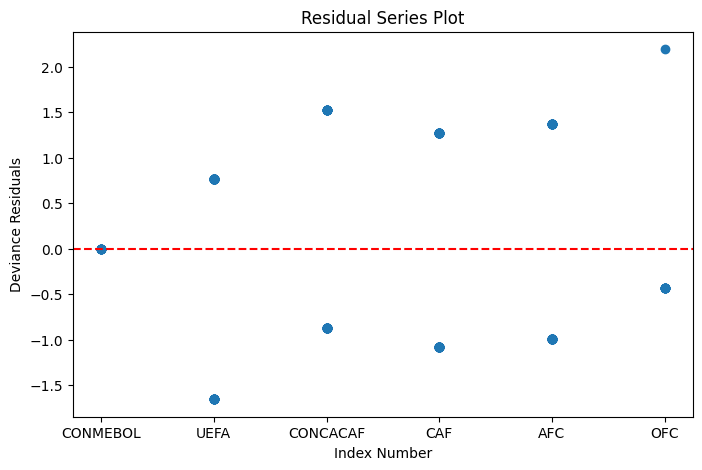

In [ ]:
#plot of residuals
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111, title="Residual Series Plot",
                    xlabel="Index Number", ylabel="Deviance Residuals")
ax.scatter(ranking['association'], mymodel.resid_dev)
plt.axhline(y=0, ls="--", color='red');

the data is collected on teams, no team depend on the other teams therefore there is no dependence in the order of the teams.
Also there's is no a cyclical patern. so the indepence assumption is met.

3. CACULATE the VIF

since we only have one predictor variable we are not concerned with the VIF

4. examine extreme residuals in logistic regression

In [ ]:
# Examine the deviance residual values
mymodel.resid_dev.describe()

count    211.000000
mean      -0.015287
std        1.087586
min       -1.654253
25%       -0.996431
50%       -0.436601
75%        1.273523
max        2.189929
dtype: float64

There are no deviance residuals greater than 3, therefore this assumption is met.

5. LINEARITY


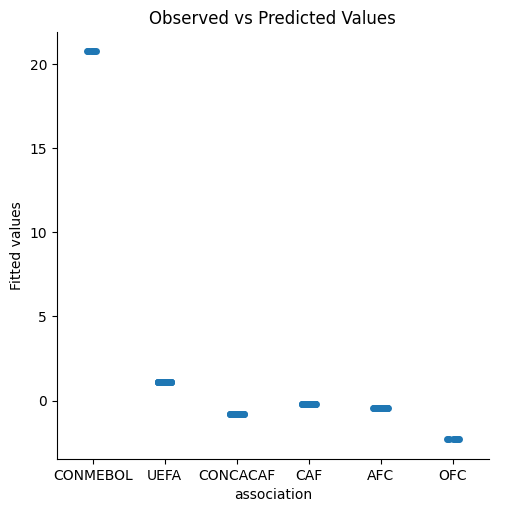

In [ ]:
#catplot of fittedvalue vs association
sns.catplot(x='association', y=mymodel.fittedvalues, data=ranking, kind='strip', jitter=True)
plt.ylabel('Fitted values')
plt.title('Observed vs Predicted Values')
plt.show()

met.

6. SUFFICIENT SAMPLE SIZE



In [ ]:
#group by region
group_by_region = ranking.groupby('association')
#count the number of observation
group_by_region.count()

,team,team_code,rank,previous_rank,points,previous_points,Top_50
association,,,,,,,
AFC,46,46,46,46,46,46,46
CAF,54,54,54,54,54,54,54
CONCACAF,35,35,35,35,35,35,35
CONMEBOL,10,10,10,10,10,10,10
OFC,11,11,11,11,11,11,11
UEFA,55,55,55,55,55,55,55


assumption is also met.

let's apppend the probabilities as a column to our dataframe, and then compare the probabilities and the observed classification of the response. we are going to use a probability of 0.50 as a cut-off between a prediction that the team will be in the top 50 vs not in the top 50

In [ ]:
#creating new variable
ranking['predictions'] = mymodel.predict()
#convert the probabilities to a yes or no
ranking.loc[ranking['predictions'] >= .50, 'Predicted_top'] = 1
ranking.loc[ranking['predictions'] < .50, 'Predicted_top'] = 0
#classification repport
print(classification_report((ranking['Top_50']), ranking['Predicted_top'].astype(float)))

              precision    recall  f1-score   support

           0       0.63      0.87      0.73       106
           1       0.78      0.49      0.60       105

    accuracy                           0.68       211
   macro avg       0.71      0.68      0.67       211
weighted avg       0.71      0.68      0.67       211



let's also calculates a 95% confidence interval around the odds ratio to build in the inherent uncertainty in our estimate.

In [ ]:
#calculate the 95% confidence interval
params = mymodel.params
conf = mymodel.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['5%', '95%', 'Odds Ratio']
print(np.exp(conf))

                                  5%        95%    Odds Ratio
Intercept                   0.355598   1.162171  6.428571e-01
C(association)[T.CAF]       0.559613   2.767344  1.244444e+00
C(association)[T.CONCACAF]  0.282061   1.802147  7.129630e-01
C(association)[T.CONMEBOL]  0.000000        inf  1.592981e+09
C(association)[T.OFC]       0.018316   1.321089  1.555556e-01
C(association)[T.UEFA]      1.951483  10.634520  4.555556e+00


/usr/local/lib/python3.10/dist-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


Let's take a look at the summary of our model.

In [ ]:
#summary
mymodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Top_50   No. Observations:                  211
Model:                          Logit   Df Residuals:                      205
Method:                           MLE   Df Model:                            5
Date:                Sun, 21 Jan 2024   Pseudo R-squ.:                  0.1506
Time:                        03:17:31   Log-Likelihood:                -124.22
converged:                      False   LL-Null:                       -146.25
Covariance Type:            nonrobust   LLR p-value:                 2.255e-08
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -0.4418      0.302     -1.462      0.144      -1.034       0.150
C(association)[T.CAF]          0.2187      0.408      0.536      0.592      -0.581       1.018
C(association)[T.CONCACAF]    -0.3383      0.473     -0.715      0.475      -1.266       0.589
C(association)[T.CONMEBOL]    21.1889   1.01e+04      0.002      0.998   -1.98e+04    1.99e+04
C(association)[T.OFC]         -1.8608      1.091     -1.705      0.088      -4.000       0.278
C(association)[T.UEFA]         1.5163      0.433      3.506      0.000       0.669       2.364
==============================================================================================
"""

the LLR p-value is less than 0.05 therefore our model is statistically significant compared to a null model. the lolg likelihood is -124.22 and this indicate that the model could be better.